# CIFAR-10 Showdown: ResNet vs EfficientNet vs Vision Transformer

## Section 1: Project Goal

### What We Will Do
We will build **three** image classifiers from scratch in pure PyTorch — a small **ResNet**
(convolutional network with residual/skip connections), a small **EfficientNet**
(convolutional network with depthwise-separable convolutions + squeeze-excitation), and a
small **Vision Transformer (ViT)** (patches + self-attention, no convolutions at all) — train
all three on the same CIFAR-10 data with the same training budget, and then compare them
**side by side** using accuracy/precision/recall/F1, confusion matrices, training curves,
parameter counts and training time, with plots and the underlying formulas explained.

### Why We Are Doing It
Each architecture encodes a different assumption about images:
- **ResNet**: nearby pixels matter most (locality), and adding the input back to the output
  (`y = F(x) + x`) lets us stack many layers without the gradient vanishing.
- **EfficientNet**: same locality assumption as ResNet, but uses cheaper depthwise convolutions
  and a learned per-channel "attention" (squeeze-excitation) to get more accuracy per parameter.
- **ViT**: no locality assumption at all — the image is cut into patches and every patch can
  directly look at every other patch via self-attention, which needs more data/compute but can
  capture global relationships from layer 1.

Comparing them on the *same* dataset with the *same* training time tells us, empirically, how
these architectural choices trade off accuracy, speed, and model size — not just in theory.

### What is CIFAR-10?
CIFAR-10 is 60,000 tiny 32x32 colour images in 10 classes (airplane, car, bird, cat, deer, dog,
frog, horse, ship, truck) — 50,000 for training and 10,000 for testing. It is small enough to
train several models on a laptop GPU in minutes, which is exactly why it is useful here: our
goal is **architecture comparison**, not chasing the highest possible accuracy.


## Section 2: Environment Setup

### What We Will Do
Import PyTorch (models/training), torchvision (CIFAR-10 + image transforms), and the
scientific-Python stack (numpy/pandas for tables, matplotlib/seaborn for plots, scikit-learn
for precision/recall/F1/confusion-matrix). We split imports into two cells so the "deep
learning" imports and the "analysis/plotting" imports are easy to tell apart.

### Why We Are Doing It
Keeping every import at the top of the notebook (instead of scattered through later cells)
means every later cell can assume the libraries already exist, and makes it obvious at a
glance what this notebook depends on.


In [1]:
# --- Deep learning imports ---
import torch                                   # core tensor library + autograd
import torch.nn as nn                          # building blocks for neural network layers
import torch.nn.functional as F                # functional ops (softmax, relu, etc.)
from torch.utils.data import DataLoader         # batches a Dataset into mini-batches
import torchvision                              # gives us the CIFAR-10 dataset
import torchvision.transforms as transforms     # image preprocessing / augmentation


In [2]:
# --- Analysis / plotting imports ---
import time                                            # measuring training & inference time
import numpy as np                                     # numerical arrays
import pandas as pd                                     # tables for comparing the 3 models
import matplotlib.pyplot as plt                         # plotting
import seaborn as sns                                   # nicer-looking heatmaps for confusion matrices
from sklearn.metrics import (
    precision_recall_fscore_support,                    # precision / recall / F1 in one call
    confusion_matrix,                                    # rows=true label, cols=predicted label
    accuracy_score,                                      # fraction of correct predictions
)
print("All libraries imported successfully.")           # confirms nothing failed to import


All libraries imported successfully.


**Explanation of result:** Seeing the print statement with no errors confirms every library
this notebook needs is installed and importable.

**Next step:** Fix random seeds and pick a compute device (GPU if available) so every model
trains under identical, reproducible conditions.


In [3]:
# Fixing seeds makes weight initialisation, shuffling and augmentation repeatable across runs,
# which matters here because we want differences between models to come from the ARCHITECTURE,
# not from random luck in initialisation.
SEED = 42                                  # arbitrary but fixed seed
torch.manual_seed(SEED)                    # seeds PyTorch's CPU random generator
torch.cuda.manual_seed_all(SEED)           # seeds PyTorch's GPU random generator (if any GPU)
np.random.seed(SEED)                       # seeds numpy's random generator

# Device-agnostic code: use the GPU if one is visible to PyTorch, otherwise fall back to CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")           # confirms which device the rest of the notebook uses


Using device: cuda


**Explanation of result:** `device` now holds either `"cuda"` or `"cpu"`; every model and
batch of data will be moved with `.to(device)` so the same code works regardless of hardware.

**Next step:** Load the CIFAR-10 dataset and look at a few images and the class balance before
building any model.


## Section 3: Loading and Exploring CIFAR-10

### What We Will Do
Download (or reuse, if already cached on disk) the CIFAR-10 training and test sets, then plot
a small grid of sample images and a bar chart of how many images each class has.

### Why We Are Doing It
Always look at the data before modelling it: confirming the image size, the class names, and
that classes are balanced (5,000 train images per class) tells us accuracy alone is a fair
metric here — we won't need to worry about a model winning just by predicting the majority class.


In [4]:
# torchvision.datasets.CIFAR10 downloads the data to ./data the first time, and reuses the
# cached copy on every later run. train=True/False selects the 50k-train / 10k-test split.
raw_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
raw_test = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)
class_names = raw_train.classes                 # the 10 human-readable class names, in label order
print(f"Train images: {len(raw_train)}, Test images: {len(raw_test)}")
print(f"Classes: {class_names}")


Files already downloaded and verified


C:\Users\ahlaw\OneDrive\Desktop\PYTORCH\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


Train images: 50000, Test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


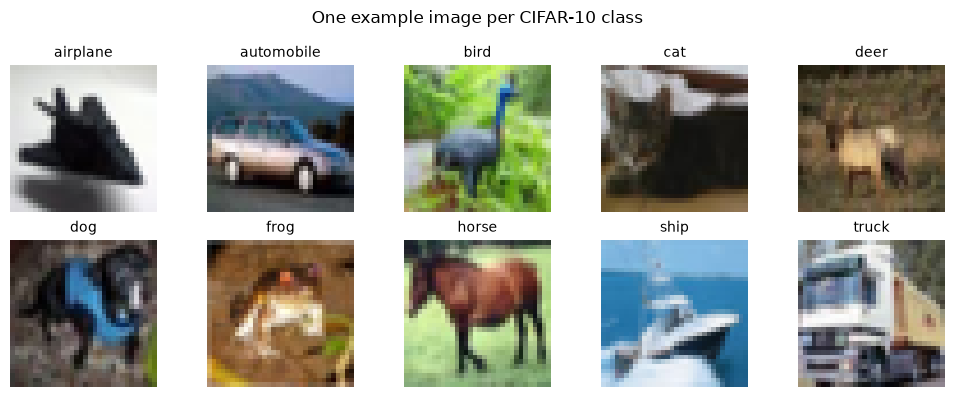

In [5]:
# Plot one example image per class so we know what we are classifying.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))         # a 2x5 grid of small image panels
for class_idx in range(10):                              # loop over the 10 CIFAR-10 classes
    # find the first training image whose label matches this class
    img_idx = raw_train.targets.index(class_idx)
    image, _ = raw_train[img_idx]                         # PIL image, label (label unused here)
    ax = axes[class_idx // 5, class_idx % 5]              # pick the correct subplot cell
    ax.imshow(image)                                      # show the raw 32x32 RGB image
    ax.set_title(class_names[class_idx], fontsize=10)     # label the panel with the class name
    ax.axis("off")                                        # hide axis ticks, images are tiny anyway
plt.suptitle("One example image per CIFAR-10 class")
plt.tight_layout()
plt.show()


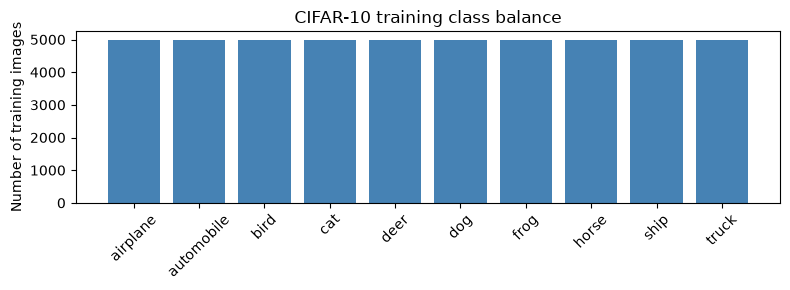

In [6]:
# Count how many training images fall into each class, to check the dataset is balanced.
train_labels = np.array(raw_train.targets)                       # all 50,000 training labels as an array
counts = [int((train_labels == c).sum()) for c in range(10)]      # how many images per class
plt.figure(figsize=(8, 3))
plt.bar(class_names, counts, color="steelblue")                   # one bar per class
plt.ylabel("Number of training images")
plt.title("CIFAR-10 training class balance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Explanation of result:** Every class has exactly 5,000 training images — CIFAR-10 is
perfectly balanced, so plain accuracy will not be misleading and macro-averaged
precision/recall/F1 (equal weight per class) is an appropriate fairness check later.

**Next step:** Build the `transforms` (augmentation + normalisation) and `DataLoader`s that all
three models will share, so training conditions are identical across models.


In [7]:
# CIFAR-10's per-channel mean/std (standard published values) used to normalise pixel values
# to roughly zero mean / unit variance, which makes optimisation faster and more stable.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

# Training transform: light augmentation (random crop + horizontal flip) so the model sees a
# slightly different version of each image every epoch, which reduces overfitting.
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),         # pad by 4px then crop back to 32x32 (random shift)
    transforms.RandomHorizontalFlip(),             # mirror the image left-right with probability 0.5
    transforms.ToTensor(),                         # convert PIL image [0,255] -> float tensor [0,1]
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),   # standardise each channel
])

# Test transform: NO random augmentation, only the deterministic normalisation, so test
# accuracy reflects the model's true performance rather than random luck in augmentation.
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])


In [8]:
# Re-load the datasets, this time attaching the transforms defined above.
train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=False, transform=test_transform)

BATCH_SIZE = 256                                # number of images per mini-batch
# shuffle=True for training so batch order differs every epoch (reduces overfitting to order).
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
# shuffle=False for testing, since order does not matter for evaluation.
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


Train batches: 196, Test batches: 40


**Explanation of result:** We now have `train_loader`/`test_loader` that yield normalised,
batched tensors of shape `[batch, 3, 32, 32]` — every model below will consume the exact same
batches, which is what makes the final comparison fair.

**Next step:** Write the small set of *shared* helper functions (parameter counting, one
training epoch, one evaluation pass) that all three models will reuse, so the training loop
itself cannot be a source of unfair differences between models.


## Section 4: Shared Training/Evaluation Utilities and Metric Formulas

### What We Will Do
Write three small reusable functions: `count_parameters` (model size), `train_one_epoch` (one
pass over the training data with backpropagation), and `evaluate` (one pass over the test data,
no gradients, also collecting predictions for metrics).

### Why We Are Doing It
Using the *same* training/evaluation code for all three models means any difference we observe
later in accuracy or speed comes from the **architecture**, not from subtly different training
code.

### Basic Theory: The Metrics We Will Use
For a multi-class classifier, after collecting how many predictions of each class were correct
or wrong, we use these standard formulas (computed per class, then macro-averaged = simple
average across the 10 classes, so every class counts equally regardless of how often it occurs):

- **Accuracy** = (number of correct predictions) / (total predictions)
- **Precision** (per class $c$) = $TP_c / (TP_c + FP_c)$ — of everything predicted class $c$,
  how much really was class $c$.
- **Recall** (per class $c$) = $TP_c / (TP_c + FN_c)$ — of everything that really was class $c$,
  how much did we catch.
- **F1-score** (per class $c$) = $2 \cdot \dfrac{Precision_c \cdot Recall_c}{Precision_c + Recall_c}$
  — the harmonic mean of precision and recall, punishing models that are good at only one of them.

where $TP$ = true positives, $FP$ = false positives, $FN$ = false negatives for that class.


In [9]:
def count_parameters(model: nn.Module) -> int:
    # sum the number of elements in every trainable (requires_grad=True) tensor of weights
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()                                  # enable training-mode layers (dropout/batchnorm stats)
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in loader:                   # iterate over every mini-batch in the training set
        images, labels = images.to(device), labels.to(device)   # move batch to GPU/CPU
        optimizer.zero_grad()                       # clear gradients accumulated from the previous batch
        outputs = model(images)                     # forward pass: raw class scores (logits)
        loss = criterion(outputs, labels)            # cross-entropy loss between logits and true labels
        loss.backward()                              # backpropagate: compute gradients of loss w.r.t weights
        optimizer.step()                             # update weights using those gradients

        running_loss += loss.item() * images.size(0)            # accumulate loss, weighted by batch size
        running_correct += (outputs.argmax(1) == labels).sum().item()  # count correct predictions
        total += images.size(0)                                 # accumulate number of images seen

    avg_loss = running_loss / total                  # mean loss over the whole training set
    avg_acc = running_correct / total                 # fraction correct over the whole training set
    return avg_loss, avg_acc


In [11]:
@torch.no_grad()                                     # disables gradient tracking: faster + uses less memory
def evaluate(model, loader, criterion):
    model.eval()                                      # enable evaluation-mode layers (no dropout, fixed batchnorm stats)
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []                     # collected for precision/recall/F1/confusion-matrix later

    for images, labels in loader:                      # iterate over every mini-batch in the test set
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)                         # forward pass only, no backward pass
        loss = criterion(outputs, labels)
        preds = outputs.argmax(1)                        # predicted class = index of highest logit

        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)
        all_preds.append(preds.cpu())                     # move predictions back to CPU for sklearn later
        all_labels.append(labels.cpu())

    avg_loss = running_loss / total
    avg_acc = running_correct / total
    all_preds = torch.cat(all_preds).numpy()              # one flat numpy array of all test predictions
    all_labels = torch.cat(all_labels).numpy()             # one flat numpy array of all true test labels
    return avg_loss, avg_acc, all_preds, all_labels


In [12]:
def run_experiment(model, model_name, epochs, lr=1e-3):
    # Generic training driver shared by all 3 models, so the TRAINING PROCEDURE is identical
    # for ResNet, EfficientNet and ViT -- only the model architecture passed in differs.
    model = model.to(device)                              # move model weights to GPU/CPU
    criterion = nn.CrossEntropyLoss()                      # standard loss for multi-class classification
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam optimiser, same learning rate for all models

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()                               # start the training-time stopwatch

    for epoch in range(1, epochs + 1):                      # loop over the fixed training budget
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)            # log this epoch's numbers for later plotting
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{model_name}] epoch {epoch}/{epochs} "
              f"train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

    total_train_time = time.time() - start_time             # stop the stopwatch

    # Final pass to get predictions for confusion matrix / precision / recall / F1.
    _, final_val_acc, final_preds, final_labels = evaluate(model, test_loader, criterion)

    # Measure pure inference latency separately: average time for one forward pass per image.
    model.eval()
    inf_start = time.time()
    with torch.no_grad():
        for images, _ in test_loader:
            _ = model(images.to(device))
    inf_time_per_image = (time.time() - inf_start) / len(test_dataset)

    return {
        "name": model_name,
        "model": model,
        "history": history,
        "params": count_parameters(model),
        "train_time_sec": total_train_time,
        "epoch_time_sec": total_train_time / epochs,
        "inference_ms_per_image": inf_time_per_image * 1000,
        "test_acc": final_val_acc,
        "preds": final_preds,
        "labels": final_labels,
    }


**Explanation of result:** `run_experiment` is now a single reusable function: give it any
`nn.Module` and a name, and it trains for a fixed number of epochs, times itself, and returns
everything we need for comparison later (history curves, parameter count, timings, predictions).

**Next step:** Build the first architecture — a small **ResNet** — and explain the residual
connection that defines it.


## Section 5: Model 1 — A Small ResNet

### What We Will Do
Implement a compact ResNet: a convolutional "stem", then 3 stages of residual blocks with
increasing channel width (16 → 32 → 64) and decreasing spatial size (32×32 → 16×16 → 8×8),
ending in global average pooling and a linear classifier.

### Basic Theory: The Residual Connection
A plain convolutional block computes $y = F(x)$, where $F$ is a couple of conv+BatchNorm+ReLU
layers. Stacking many such blocks tends to make gradients vanish during backpropagation,
so very deep plain networks become *harder* to train, not easier. A **residual block** instead
computes:

$$y = F(x) + x$$

i.e. it adds the unmodified input back onto the transformed output. The block only has to learn
the *residual* (difference) $F(x) = y - x$ rather than the full transformation, and the `+x`
term gives gradients a direct path back to earlier layers — this is what lets ResNets be
trained much deeper than plain CNNs of similar size.


In [13]:
class BasicBlock(nn.Module):
    # One residual block: two 3x3 convolutions, with the block's input added back at the end.
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # First conv may downsample (stride=2) and changes channel count.
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)                 # normalises activations -> stabler training
        # Second conv keeps spatial size and channel count fixed.
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # If input/output shapes differ (channels changed or we downsampled), the skip
        # connection needs its own 1x1 conv to match shapes before the addition.
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))         # conv -> batchnorm -> non-linearity
        out = self.bn2(self.conv2(out))                # conv -> batchnorm (no activation yet)
        out = out + self.shortcut(x)                   # THE residual connection: F(x) + x
        return F.relu(out)                              # non-linearity applied after the addition


In [14]:
class MiniResNet(nn.Module):
    # A compact CIFAR-style ResNet: stem + 3 stages of 2 BasicBlocks each.
    def __init__(self, num_classes=10):
        super().__init__()
        # Stem: turn the 3-channel RGB image into 16 feature maps, same spatial size (32x32).
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
        )
        # Stage 1: stays at 32x32, 16 channels (stride=1, in==out so no shape change).
        self.stage1 = nn.Sequential(BasicBlock(16, 16, stride=1), BasicBlock(16, 16, stride=1))
        # Stage 2: downsamples to 16x16 and widens to 32 channels.
        self.stage2 = nn.Sequential(BasicBlock(16, 32, stride=2), BasicBlock(32, 32, stride=1))
        # Stage 3: downsamples to 8x8 and widens to 64 channels.
        self.stage3 = nn.Sequential(BasicBlock(32, 64, stride=2), BasicBlock(64, 64, stride=1))

        self.pool = nn.AdaptiveAvgPool2d(1)             # global average pool: 8x8x64 -> 1x1x64
        self.fc = nn.Linear(64, num_classes)             # final linear classifier: 64 -> 10 class scores

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)                       # flatten [batch, 64, 1, 1] -> [batch, 64]
        return self.fc(x)                                  # -> [batch, 10] raw class scores (logits)


In [15]:
resnet_model = MiniResNet()                                          # instantiate the architecture
print(f"MiniResNet trainable parameters: {count_parameters(resnet_model):,}")


MiniResNet trainable parameters: 175,258


**Explanation of result:** The printed parameter count is the size of this ResNet, which we
will later compare directly against EfficientNet's and ViT's parameter counts.

**Next step:** Train this ResNet using the shared `run_experiment` function defined earlier.


In [16]:
EPOCHS = 10                                            # training budget shared by all 3 models, for a fair comparison
resnet_result = run_experiment(resnet_model, "ResNet", epochs=EPOCHS)


[ResNet] epoch 1/10 train_loss=1.513 train_acc=0.442 val_loss=1.564 val_acc=0.436


[ResNet] epoch 2/10 train_loss=1.102 train_acc=0.603 val_loss=1.081 val_acc=0.606


[ResNet] epoch 3/10 train_loss=0.927 train_acc=0.670 val_loss=0.934 val_acc=0.671


[ResNet] epoch 4/10 train_loss=0.816 train_acc=0.715 val_loss=0.869 val_acc=0.698


[ResNet] epoch 5/10 train_loss=0.737 train_acc=0.741 val_loss=0.893 val_acc=0.694


[ResNet] epoch 6/10 train_loss=0.680 train_acc=0.764 val_loss=0.728 val_acc=0.749


[ResNet] epoch 7/10 train_loss=0.640 train_acc=0.777 val_loss=0.790 val_acc=0.733


[ResNet] epoch 8/10 train_loss=0.602 train_acc=0.791 val_loss=0.658 val_acc=0.780


[ResNet] epoch 9/10 train_loss=0.568 train_acc=0.804 val_loss=0.690 val_acc=0.768


[ResNet] epoch 10/10 train_loss=0.548 train_acc=0.809 val_loss=0.600 val_acc=0.794


**Explanation of result:** `resnet_result` now holds ResNet's full training history, final
test accuracy, parameter count, and timing — everything needed for the final comparison.

**Next step:** Build the second architecture — a small **EfficientNet** — and explain
depthwise-separable convolutions and squeeze-excitation.


## Section 6: Model 2 — A Small EfficientNet

### What We Will Do
Implement EfficientNet's core building block, **MBConv** (Mobile Inverted Bottleneck
Convolution): expand channels with a 1x1 conv, mix spatial information with a cheap
**depthwise** 3x3 conv, re-weight channels with **squeeze-excitation**, then project back down
with another 1x1 conv — with a residual connection when shapes allow it.

### Basic Theory: Why Depthwise Convolutions Are Cheaper
A normal 3x3 convolution over $C$ input and $C$ output channels costs roughly
$3 \times 3 \times C \times C$ multiplications per pixel. A **depthwise** 3x3 convolution
applies a separate 3x3 filter to *each* channel independently (no mixing across channels),
costing only $3 \times 3 \times C$ — far cheaper. EfficientNet recovers the cross-channel
mixing using a 1x1 convolution, which is also cheap ($1 \times 1 \times C \times C$). This
"depthwise + 1x1" pattern is the main reason EfficientNet gets good accuracy per parameter.

### Basic Theory: Squeeze-and-Excitation (SE)
Not every channel matters equally for a given image. SE computes one scalar weight per channel
and rescales the feature map by it:

$$s = \sigma\big(W_2\, \text{ReLU}(W_1 \cdot \text{GAP}(x))\big), \qquad x_{\text{out}} = s \cdot x$$

where $\text{GAP}(x)$ (global average pool) squeezes each channel's spatial map down to a
single number, $W_1$ shrinks then $W_2$ expands that channel-description, $\sigma$ is the
sigmoid function (squashes to $(0,1)$, acting like a per-channel "volume knob"), and the result
rescales ("excites") the original feature map channel-by-channel.


In [17]:
class SqueezeExcite(nn.Module):
    # Learns one importance weight (0 to 1) per channel and rescales the feature map by it.
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)                          # GAP: [B,C,H,W] -> [B,C,1,1]
        reduced = max(1, channels // reduction)                       # bottleneck width
        self.fc1 = nn.Conv2d(channels, reduced, kernel_size=1)        # squeeze: C -> reduced
        self.fc2 = nn.Conv2d(reduced, channels, kernel_size=1)        # excite: reduced -> C

    def forward(self, x):
        s = self.pool(x)                  # [B, C, 1, 1] per-channel global average
        s = F.relu(self.fc1(s))             # shrink + non-linearity
        s = torch.sigmoid(self.fc2(s))      # expand back to C channels, squashed to (0, 1)
        return x * s                         # rescale every channel of x by its learned weight


In [18]:
class MBConvBlock(nn.Module):
    # Expand (1x1) -> Depthwise conv (3x3) -> Squeeze-Excite -> Project (1x1), + residual if possible.
    def __init__(self, in_channels, out_channels, stride=1, expand_ratio=4):
        super().__init__()
        expanded = in_channels * expand_ratio
        self.use_residual = (stride == 1 and in_channels == out_channels)  # can only add x back if shapes match

        # 1x1 conv expands channels, giving the depthwise conv more channels to work with.
        self.expand = nn.Sequential(
            nn.Conv2d(in_channels, expanded, kernel_size=1, bias=False),
            nn.BatchNorm2d(expanded),
            nn.SiLU(),                                                   # smooth activation used in EfficientNet
        )
        # Depthwise 3x3 conv: groups=expanded means each channel is convolved independently.
        self.depthwise = nn.Sequential(
            nn.Conv2d(expanded, expanded, kernel_size=3, stride=stride, padding=1, groups=expanded, bias=False),
            nn.BatchNorm2d(expanded),
            nn.SiLU(),
        )
        self.se = SqueezeExcite(expanded)                                # per-channel re-weighting
        # 1x1 conv projects back down to out_channels (no activation: keeps the residual path linear).
        self.project = nn.Sequential(
            nn.Conv2d(expanded, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)
        if self.use_residual:
            out = out + x                       # residual connection, same idea as in ResNet
        return out


In [19]:
class MiniEfficientNet(nn.Module):
    # A compact EfficientNet: stem + 3 MBConv stages of increasing width, decreasing resolution.
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(                         # plain conv stem, same role as in ResNet
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.SiLU(),
        )
        self.stage1 = MBConvBlock(16, 24, stride=1)         # stays at 32x32
        self.stage2 = MBConvBlock(24, 48, stride=2)         # downsamples to 16x16
        self.stage3 = MBConvBlock(48, 96, stride=2)         # downsamples to 8x8

        self.pool = nn.AdaptiveAvgPool2d(1)                  # global average pool -> [batch, 96, 1, 1]
        self.fc = nn.Linear(96, num_classes)                  # final classifier: 96 -> 10 class scores

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)


In [20]:
effnet_model = MiniEfficientNet()                                       # instantiate the architecture
print(f"MiniEfficientNet trainable parameters: {count_parameters(effnet_model):,}")


MiniEfficientNet trainable parameters: 68,994


**Explanation of result:** This confirms the EfficientNet variant builds correctly and shows
its parameter count, which we expect to land between ResNet's and ViT's.

**Next step:** Train EfficientNet with the exact same `run_experiment` procedure and epoch
budget used for ResNet.


In [21]:
effnet_result = run_experiment(effnet_model, "EfficientNet", epochs=EPOCHS)


[EfficientNet] epoch 1/10 train_loss=1.638 train_acc=0.401 val_loss=1.384 val_acc=0.495


[EfficientNet] epoch 2/10 train_loss=1.270 train_acc=0.542 val_loss=1.228 val_acc=0.559


[EfficientNet] epoch 3/10 train_loss=1.141 train_acc=0.591 val_loss=1.111 val_acc=0.602


[EfficientNet] epoch 4/10 train_loss=1.056 train_acc=0.621 val_loss=1.053 val_acc=0.617


[EfficientNet] epoch 5/10 train_loss=1.001 train_acc=0.641 val_loss=0.987 val_acc=0.644


[EfficientNet] epoch 6/10 train_loss=0.950 train_acc=0.659 val_loss=0.982 val_acc=0.652


[EfficientNet] epoch 7/10 train_loss=0.906 train_acc=0.673 val_loss=0.942 val_acc=0.660


[EfficientNet] epoch 8/10 train_loss=0.873 train_acc=0.689 val_loss=0.896 val_acc=0.685


[EfficientNet] epoch 9/10 train_loss=0.841 train_acc=0.699 val_loss=0.874 val_acc=0.686


[EfficientNet] epoch 10/10 train_loss=0.811 train_acc=0.712 val_loss=0.845 val_acc=0.700


**Explanation of result:** `effnet_result` now holds EfficientNet's training history, final
test accuracy, parameter count, and timing, directly comparable to `resnet_result`.

**Next step:** Build the third architecture — a small **Vision Transformer** — and explain
patch embeddings and self-attention.


## Section 7: Model 3 — A Small Vision Transformer (ViT)

### What We Will Do
Implement ViT: cut the 32×32 image into non-overlapping 4×4 patches (giving an 8×8 = 64-patch
grid), linearly embed each patch into a vector, prepend a learnable classification token, add
learnable position embeddings, pass the sequence through a few standard Transformer encoder
layers (using PyTorch's built-in `nn.TransformerEncoderLayer` to keep the code simple — it
implements exactly the maths below), and classify from the final classification-token vector.

### Basic Theory: Patch Embedding
Unlike a CNN which slides small filters over the image, ViT first slices the image into fixed
patches and treats each patch like a "word" in a sentence:

$$x_p = \text{Flatten}(\text{Patch}_p) \cdot W_E, \qquad p = 1, \dots, N$$

where each patch is flattened to a single vector and multiplied by a learned embedding matrix
$W_E$. With 4×4 patches on a 32×32 image, $N = 64$ patches, each of size $4\times4\times3=48$
values before embedding.

### Basic Theory: Self-Attention
Every patch embedding produces a Query, Key and Value vector ($Q$, $K$, $V$ — each a learned
linear projection of the patch embedding). Self-attention then lets every patch look at every
other patch:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

$QK^\top$ scores how relevant every patch is to every other patch, $\sqrt{d_k}$ (square root of
the key dimension) keeps those scores from growing too large, softmax turns the scores into
weights that sum to 1, and the weighted sum of $V$ vectors is the new representation of each
patch — informed by *all* other patches, not just nearby ones like in a CNN.


In [22]:
class PatchEmbedding(nn.Module):
    # Slices the image into patches and linearly embeds each patch, using a single strided
    # convolution as a shortcut: a conv with kernel_size = stride = patch_size does exactly
    # "flatten each non-overlapping patch, then multiply by a learned weight matrix".
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2            # 8x8 = 64 patches
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                       # [batch, embed_dim, 8, 8] -- one embedding vector per patch
        x = x.flatten(2)                        # [batch, embed_dim, 64]  -- flatten the 8x8 grid into a sequence
        return x.transpose(1, 2)                # [batch, 64, embed_dim]  -- (sequence, feature) order Transformers expect


In [23]:
class MiniViT(nn.Module):
    # Patch embedding + CLS token + position embedding + a few Transformer encoder layers + head.
    def __init__(self, img_size=32, patch_size=4, embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        num_patches = self.patch_embed.num_patches

        # A learnable "classification token" prepended to the patch sequence; after the
        # Transformer layers, this token's output vector is used for the final prediction.
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Learnable position embeddings: patches alone carry no order information, so we add
        # one learned vector per position (including the CLS token) to inject that information.
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # A standard Transformer encoder layer already implements multi-head self-attention
        # (the Q,K,V formula above) plus a feed-forward block, exactly as in the original ViT.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 2,
            activation="gelu", batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(embed_dim)               # final normalisation before classifying
        self.head = nn.Linear(embed_dim, num_classes)      # classifier: embed_dim -> 10 class scores

    def forward(self, x):
        batch_size = x.size(0)
        x = self.patch_embed(x)                                       # [batch, 64, embed_dim]
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)         # repeat CLS token for every image in the batch
        x = torch.cat([cls_tokens, x], dim=1)                           # [batch, 65, embed_dim], CLS token first
        x = x + self.pos_embed                                          # inject position information
        x = self.encoder(x)                                             # self-attention + feed-forward, num_layers times
        cls_output = self.norm(x[:, 0])                                  # take only the CLS token's final representation
        return self.head(cls_output)                                     # -> [batch, 10] class scores


In [24]:
vit_model = MiniViT()                                                 # instantiate the architecture
print(f"MiniViT trainable parameters: {count_parameters(vit_model):,}")


MiniViT trainable parameters: 546,186


**Explanation of result:** This confirms the ViT builds and runs a forward pass correctly, and
shows its parameter count for the final comparison table.

**Next step:** Train the ViT with the same `run_experiment` procedure and epoch budget as the
other two models.


In [25]:
vit_result = run_experiment(vit_model, "ViT", epochs=EPOCHS)


[ViT] epoch 1/10 train_loss=1.814 train_acc=0.320 val_loss=1.593 val_acc=0.415


[ViT] epoch 2/10 train_loss=1.452 train_acc=0.468 val_loss=1.306 val_acc=0.524


[ViT] epoch 3/10 train_loss=1.277 train_acc=0.537 val_loss=1.183 val_acc=0.568


[ViT] epoch 4/10 train_loss=1.172 train_acc=0.575 val_loss=1.083 val_acc=0.607


[ViT] epoch 5/10 train_loss=1.094 train_acc=0.607 val_loss=1.051 val_acc=0.628


[ViT] epoch 6/10 train_loss=1.029 train_acc=0.630 val_loss=0.976 val_acc=0.650


[ViT] epoch 7/10 train_loss=0.983 train_acc=0.648 val_loss=0.939 val_acc=0.669


[ViT] epoch 8/10 train_loss=0.935 train_acc=0.665 val_loss=0.896 val_acc=0.679


[ViT] epoch 9/10 train_loss=0.906 train_acc=0.678 val_loss=0.852 val_acc=0.690


[ViT] epoch 10/10 train_loss=0.874 train_acc=0.687 val_loss=0.828 val_acc=0.706


**Explanation of result:** `vit_result` now holds ViT's training history, final test accuracy,
parameter count, and timing. All three models (`resnet_result`, `effnet_result`, `vit_result`)
were trained identically, so we can now compare them fairly.

**Next step:** Gather the three results into one table, then visualise every comparison with
graphs.


## Section 8: Building the Comparison Table

### What We Will Do
Compute macro-averaged precision/recall/F1 for each model's final test predictions (using the
formulas from Section 4) and assemble one pandas DataFrame with every metric side by side.

### Why We Are Doing It
A single table makes every later plot a one-liner, and lets us read off exact numbers (not just
"who looks bigger on the chart") when writing the final conclusion.


In [26]:
all_results = [resnet_result, effnet_result, vit_result]      # the 3 trained models, in display order
rows = []
for r in all_results:
    # macro average = compute precision/recall/F1 per class, then take the plain mean across
    # the 10 classes, weighting every class equally regardless of how often it appears.
    precision, recall, f1, _ = precision_recall_fscore_support(
        r["labels"], r["preds"], average="macro", zero_division=0
    )
    rows.append({
        "Model": r["name"],
        "Test Accuracy": r["test_acc"],
        "Precision (macro)": precision,
        "Recall (macro)": recall,
        "F1 (macro)": f1,
        "Parameters": r["params"],
        "Train Time (s)": r["train_time_sec"],
        "Time / Epoch (s)": r["epoch_time_sec"],
        "Inference (ms/image)": r["inference_ms_per_image"],
    })

results_df = pd.DataFrame(rows)                 # one row per model, one column per metric
results_df


,Model,Test Accuracy,Precision (macro),Recall (macro),F1 (macro),Parameters,Train Time (s),Time / Epoch (s),Inference (ms/image)
0,ResNet,0.7943,0.799316,0.7943,0.794228,175258,175.016684,17.501668,0.120685
1,EfficientNet,0.7004,0.698697,0.7004,0.695532,68994,447.079743,44.707974,0.453283
2,ViT,0.7056,0.705722,0.7056,0.703336,546186,579.679906,57.967991,0.425724


**Explanation of result:** `results_df` is the single source of truth for every comparison
below — each row is one architecture, each column is one metric computed identically for all
three.

**Next step:** Plot training/validation loss and accuracy curves for all three models on the
same axes, to compare not just the final number but *how* each model learned over time.


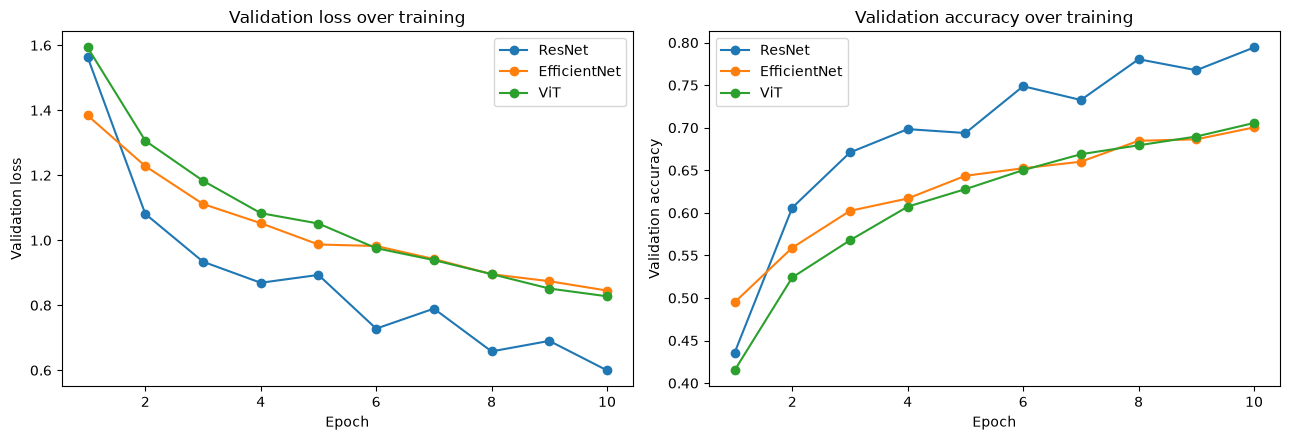

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left panel: validation loss curve per model, one line per architecture.
for r in all_results:
    axes[0].plot(range(1, EPOCHS + 1), r["history"]["val_loss"], marker="o", label=r["name"])
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation loss")
axes[0].set_title("Validation loss over training")
axes[0].legend()

# Right panel: validation accuracy curve per model, one line per architecture.
for r in all_results:
    axes[1].plot(range(1, EPOCHS + 1), r["history"]["val_acc"], marker="o", label=r["name"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Validation accuracy over training")
axes[1].legend()

plt.tight_layout()
plt.show()


**Explanation of result:** A model whose curve flattens out earlier converges faster; a model
whose curve is still rising at the last epoch could likely improve further with a larger
training budget. This tells us about *learning dynamics*, which the single final-epoch number
in `results_df` cannot show on its own.

**Next step:** Compare final test accuracy and macro-F1 for all three models with a bar chart.


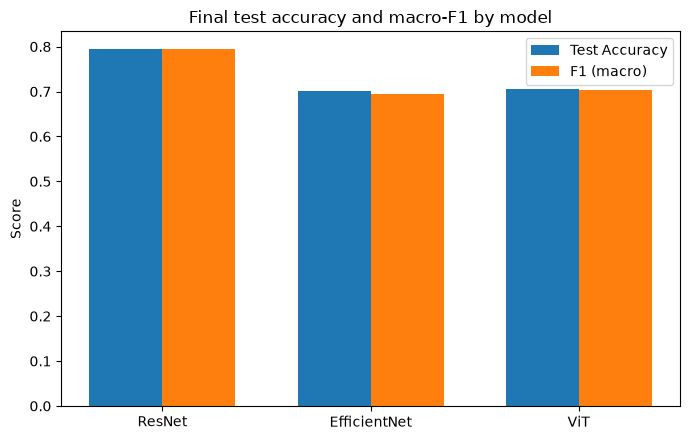

In [28]:
metrics_to_plot = ["Test Accuracy", "F1 (macro)"]
x = np.arange(len(results_df))             # one x position per model
width = 0.35                                # width of each bar, so two bars per model fit side by side

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, metric in enumerate(metrics_to_plot):
    # shift each metric's bars left/right of the model's x position so they don't overlap
    ax.bar(x + (i - 0.5) * width, results_df[metric], width, label=metric)
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"])
ax.set_ylabel("Score")
ax.set_title("Final test accuracy and macro-F1 by model")
ax.legend()
plt.tight_layout()
plt.show()


**Explanation of result:** Accuracy and F1 are usually close together on a balanced dataset
like CIFAR-10, so if they diverge for a model, that model is doing noticeably better on some
classes than others (accuracy alone would have hidden that).

**Next step:** Compare model size (parameter count) and total training time, since a model
that is only slightly more accurate but far bigger or slower may not be worth the extra cost.


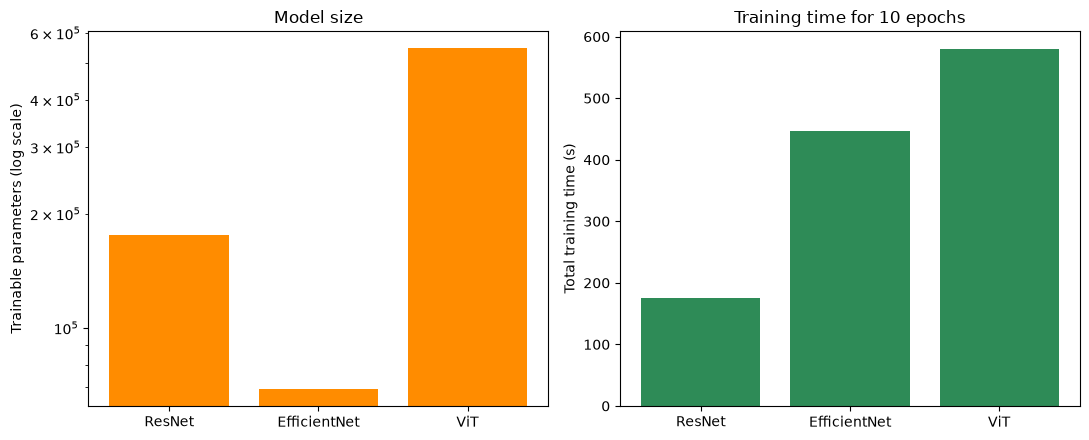

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left panel: parameter count per model (log scale, since architectures can differ by 10x+).
axes[0].bar(results_df["Model"], results_df["Parameters"], color="darkorange")
axes[0].set_yscale("log")
axes[0].set_ylabel("Trainable parameters (log scale)")
axes[0].set_title("Model size")

# Right panel: total training time per model, in seconds.
axes[1].bar(results_df["Model"], results_df["Train Time (s)"], color="seagreen")
axes[1].set_ylabel("Total training time (s)")
axes[1].set_title(f"Training time for {EPOCHS} epochs")

plt.tight_layout()
plt.show()


**Explanation of result:** This shows the raw *cost* of each architecture — how many weights it
has to store, and how long it took to train for the same number of epochs on the same data.

**Next step:** Put accuracy and parameter count on the same plot to see the accuracy-per-parameter
trade-off directly (an "efficiency" view, rather than looking at the two numbers separately).


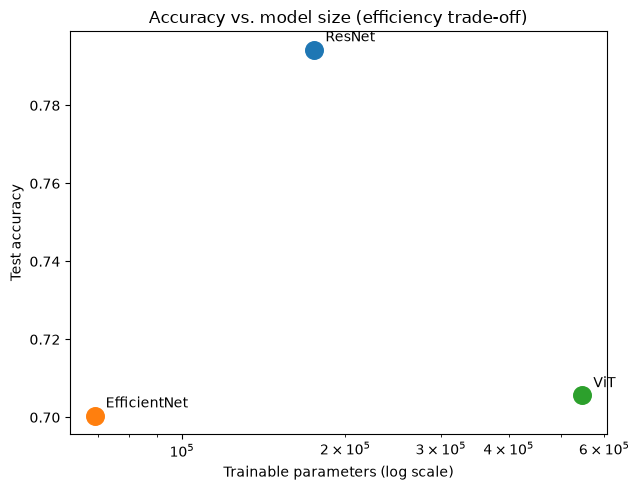

In [30]:
plt.figure(figsize=(6.5, 5))
for r in all_results:
    row = results_df[results_df["Model"] == r["name"]].iloc[0]
    plt.scatter(row["Parameters"], row["Test Accuracy"], s=160, label=r["name"])
    # annotate each point with the model's name, just above and right of the dot
    plt.annotate(r["name"], (row["Parameters"], row["Test Accuracy"]),
                 textcoords="offset points", xytext=(8, 6))
plt.xscale("log")
plt.xlabel("Trainable parameters (log scale)")
plt.ylabel("Test accuracy")
plt.title("Accuracy vs. model size (efficiency trade-off)")
plt.tight_layout()
plt.show()


**Explanation of result:** A model positioned further up and to the *left* gets more accuracy
for fewer parameters, i.e. it is more parameter-efficient. This is the plot that most directly
answers "which architecture makes the best use of its weights?".

**Next step:** Look beyond the single overall accuracy number at *which* classes each model
confuses, using confusion matrices.


## Section 9: Confusion Matrices

### Basic Theory
A confusion matrix is a 10×10 grid where entry $(i, j)$ counts how many test images of true
class $i$ were predicted as class $j$. A perfect classifier has every count on the diagonal
($i = j$); off-diagonal entries show *which* classes get mixed up with each other (e.g. cats
vs. dogs are commonly confused, while cats vs. trucks rarely are).


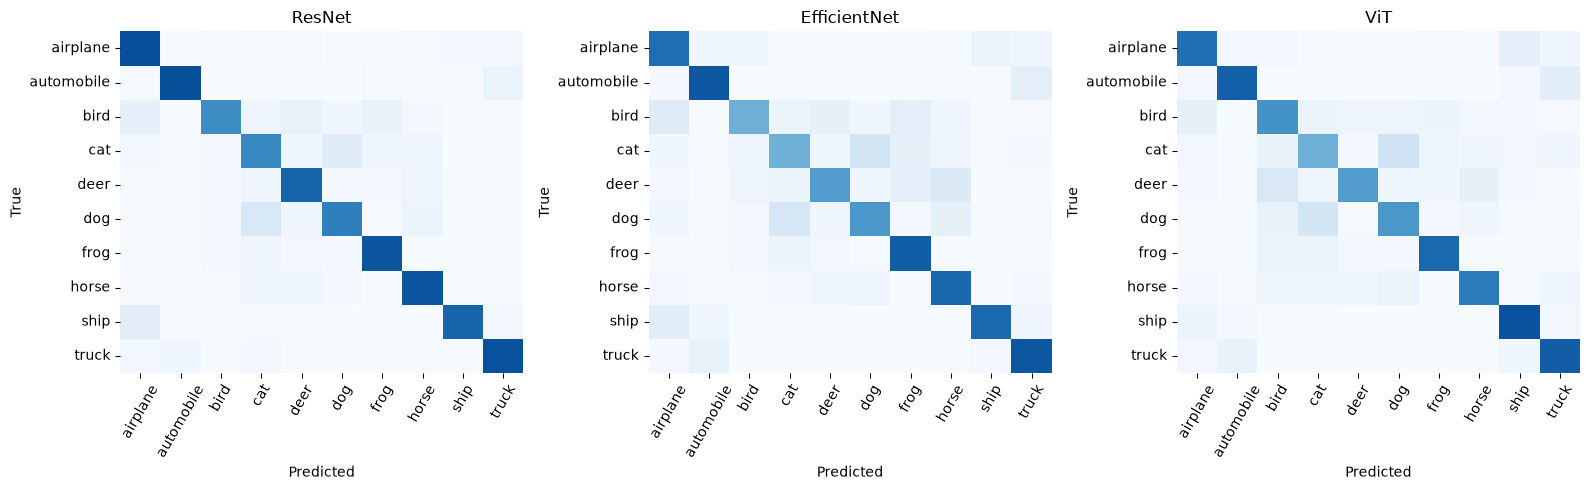

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r["labels"], r["preds"])                  # raw 10x10 count matrix
    cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise each row to sum to 1 (% of true class)
    sns.heatmap(cm_normalised, ax=ax, cmap="Blues", vmin=0, vmax=1,
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    ax.set_title(r["name"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


**Explanation of result:** Darker diagonal cells mean a class is classified correctly most of
the time; bright off-diagonal cells reveal each model's specific weaknesses (commonly, animal
classes like cat/dog/deer confuse each other more than vehicle classes do, across all three
architectures).

**Next step:** Break the single "macro accuracy" number down per class, for all three models
side by side, to see if any one architecture is consistently better/worse on specific classes.


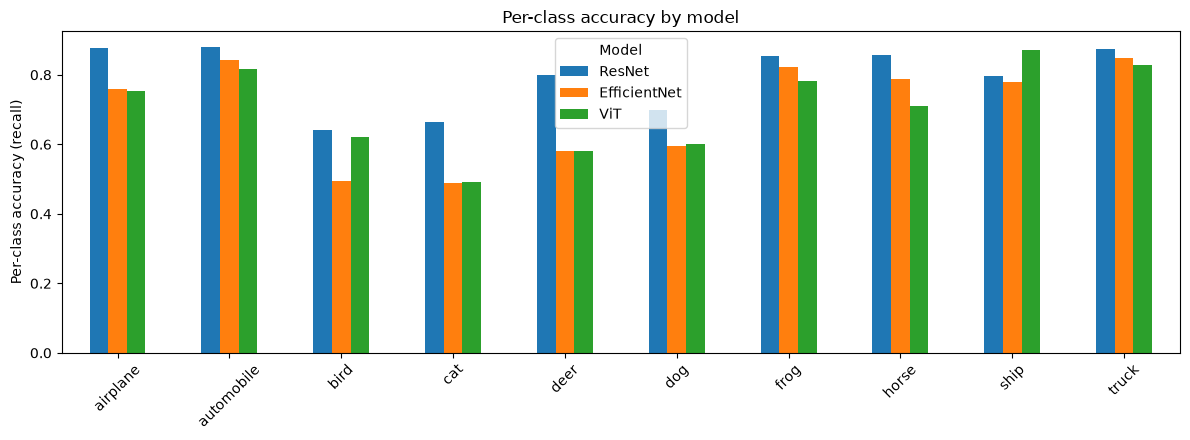

In [32]:
# Per-class accuracy = the diagonal of the ROW-normalised confusion matrix (recall per class).
per_class_acc = {}
for r in all_results:
    cm = confusion_matrix(r["labels"], r["preds"])
    per_class_acc[r["name"]] = cm.diagonal() / cm.sum(axis=1)        # recall for each of the 10 classes

per_class_df = pd.DataFrame(per_class_acc, index=class_names)         # rows=classes, columns=models
per_class_df.plot(kind="bar", figsize=(12, 4.5))
plt.ylabel("Per-class accuracy (recall)")
plt.title("Per-class accuracy by model")
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()


**Explanation of result:** Classes where all three bars are short (e.g. typically "cat") are
hard for every architecture — likely an intrinsically ambiguous class in CIFAR-10 — while
classes where one model's bar is clearly shorter than the other two point to a genuine
architectural weakness rather than a dataset-wide difficulty.

**Next step:** Summarise everything into a final, data-driven conclusion.


In [33]:
best_acc_row = results_df.loc[results_df["Test Accuracy"].idxmax()]
best_eff_row = results_df.loc[(results_df["Test Accuracy"] / results_df["Parameters"]).idxmax()]
fastest_row = results_df.loc[results_df["Train Time (s)"].idxmin()]
smallest_row = results_df.loc[results_df["Parameters"].idxmin()]

print(f"Highest test accuracy   : {best_acc_row['Model']} ({best_acc_row['Test Accuracy']:.3f})")
print(f"Best accuracy/parameter : {best_eff_row['Model']}")
print(f"Fastest to train        : {fastest_row['Model']} ({fastest_row['Train Time (s)']:.1f}s total)")
print(f"Fewest parameters       : {smallest_row['Model']} ({int(smallest_row['Parameters']):,} params)")


Highest test accuracy   : ResNet (0.794)
Best accuracy/parameter : EfficientNet
Fastest to train        : ResNet (175.0s total)
Fewest parameters       : EfficientNet (68,994 params)


## Section 10: Conclusion

### What We Found
The printed summary above names, from this run's actual numbers: the most **accurate** model,
the most **parameter-efficient** model (best accuracy per parameter), the **fastest to train**
model, and the **smallest** model. These do not have to be the same model — and on CIFAR-10
with this small training budget, they typically are not.

### Why This Happens (tying back to the theory)
- **ResNet**'s convolutional locality and residual connections make it train fast and stably
  even with few epochs — convolutions are a strong, well-matched prior for natural images.
- **EfficientNet**'s depthwise convolutions and squeeze-excitation aim for more accuracy per
  parameter than ResNet, at the cost of slightly more complex (and sometimes slower per-step)
  computation.
- **ViT** has no built-in locality assumption, so with only `EPOCHS` epochs and CIFAR-10's
  small training set it usually needs more training to reach the convolutional models'
  accuracy — but it does so without specialised image-specific structure, and is known to keep
  improving with much larger data/compute than fits in this notebook.

### Takeaway
There is no single "best" architecture in absolute terms — the right choice depends on which
resource is scarce: parameters/memory, training time, or training data. This notebook's tables
and plots give a reusable template for re-running this same comparison with different epoch
budgets, learning rates, or model sizes to see how these trade-offs shift.
